In [1]:
import torch
import py3Dmol
import requests

The code cell below lets us know that this notebook is running from `.venv`.

In [2]:
import sys
print(sys.executable)

/Users/sahilpatil/DeepLearning_for_Biology/.venv/bin/python


Need to verify if this notebook and venv can "see" my Mac's GPU.

In [3]:
if torch.backends.mps.is_available():
    print("MPS device found! You can train on your Mac's GPU.")
else:
    print("MPS not available. Using CPU.")

MPS device found! You can train on your Mac's GPU.


In [4]:
import torch
import jax
import dlfb
import Bio
import pandas as pd

# print(f"✅ dlfb version: {dlfb.__version__}")
print(f"✅ Biopython version: {Bio.__version__}")

# Check Apple Silicon GPU Acceleration
mps_available = torch.backends.mps.is_available()
jax_devices = jax.devices()

print(f"🚀 PyTorch MPS (GPU) Available: {mps_available}")
print(f"🚀 JAX Devices: {jax_devices}")

if mps_available:
    # Quick test to move a tensor to GPU
    x = torch.ones(3, 3).to("mps")
    print("✨ PyTorch tensor successfully moved to Mac GPU!")

✅ Biopython version: 1.86
🚀 PyTorch MPS (GPU) Available: True
🚀 JAX Devices: [CpuDevice(id=0)]
✨ PyTorch tensor successfully moved to Mac GPU!


In [5]:
def fetch_protein_structure(pdb_id: str) -> str:
  """Grab a PDB protein structure from the RCSB Protein Data Bank."""
  url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
  response = requests.get(url)
  return response.text


# The Protein Data Bank (PDB) is the main database of protein structures.
# Each structure has a unique 4-character PDB ID. Below are a few examples.
protein_to_pdb = {
  "insulin": "3I40",  # Human insulin – regulates glucose uptake.
  "collagen": "1BKV",  # Human collagen – provides structural support.
  "proteasome": "1YAR",  # Archaebacterial proteasome – degrades proteins.
}

protein = "insulin"  # @param ["insulin", "collagen", "proteasome"]
pdb_structure = fetch_protein_structure(pdb_id=protein_to_pdb[protein])

pdbview = py3Dmol.view(width=900, height=300)
pdbview.addModel(pdb_structure, "pdb")
pdbview.setStyle({"cartoon": {"color": "spectrum"}})
pdbview.zoomTo()
pdbview.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Let's start by loading the data. O'Reilly authors pulled data for this chapter from the CAFA (Critical Assessment of Functional Annotation) website. CAFA is an ongoing community-driven experiment to use computational methods to predict protein function. It has become a central benchmark in comp bio & bioinformatics.

In [ ]:
#  In the cell below, we load the label file, which tells us the functional annotations for each protein. The "aspect" column tells us the Gene Ontology (GO) category that the protein belongs to. 
#  There are 3 categories:
#      1) Biological Process (BPO)
#          - Eg. Cell division, immune signaling, metabolism
#      2) Molecular Function (MFO)
#          - Describes specific biochemical activity of protein itself
#          - Eg. Acting as an enzyme, transporting ions across membranes
#      3) Cellular Component (CCO)
#          - Indicates where in the cell protein resides. While technically a location label, a protein's location can tell us a lot about its broader role.
#          - Eg. Nucleus, mitochondria, cell membrane

In [7]:
cafa3_labels = pd.read_csv("../data/proteins/datasets/train_terms.tsv.zip", sep="\t", compression="infer")
cafa3_labels

,EntryID,term,aspect
0,A0A009IHW8,GO:0008152,BPO
1,A0A009IHW8,GO:0034655,BPO
2,A0A009IHW8,GO:0072523,BPO
3,A0A009IHW8,GO:0044270,BPO
4,A0A009IHW8,GO:0006753,BPO
...,...,...,...
5363858,X5L565,GO:0050649,MFO
5363859,X5L565,GO:0016491,MFO
5363860,X5M5N0,GO:0005515,MFO
5363861,X5M5N0,GO:0005488,MFO


In [8]:
from dlfb.proteins.dataset import get_go_term_descriptions
import obonet
import tensorflow

go_term_descrip = get_go_term_descriptions("../data/proteins/datasets/go_term_descriptions.csv")
go_term_descrip

/Users/sahilpatil/DeepLearning_for_Biology/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,term,description
0,GO:0000001,mitochondrion inheritance
1,GO:0000002,mitochondrial genome maintenance
2,GO:0000006,high-affinity zinc transmembrane transporter a...
3,GO:0000007,low-affinity zinc ion transmembrane transporte...
4,GO:0000009,"alpha-1,6-mannosyltransferase activity"
...,...,...
40209,GO:2001313,UDP-4-deoxy-4-formamido-beta-L-arabinopyranose...
40210,GO:2001314,UDP-4-deoxy-4-formamido-beta-L-arabinopyranose...
40211,GO:2001315,UDP-4-deoxy-4-formamido-beta-L-arabinopyranose...
40212,GO:2001316,kojic acid metabolic process


In [9]:
cafa3 = pd.merge(left=cafa3_labels, right=go_term_descrip, on="term")
cafa3

,EntryID,term,aspect,description
0,A0A009IHW8,GO:0008152,BPO,metabolic process
1,A0A009IHW8,GO:0034655,BPO,nucleobase-containing compound catabolic process
2,A0A009IHW8,GO:0072523,BPO,purine-containing compound catabolic process
3,A0A009IHW8,GO:0006753,BPO,nucleoside phosphate metabolic process
4,A0A009IHW8,GO:1901292,BPO,nucleoside phosphate catabolic process
...,...,...,...,...
4933953,X5L565,GO:0050649,MFO,testosterone 6-beta-hydroxylase activity
4933954,X5L565,GO:0016491,MFO,oxidoreductase activity
4933955,X5M5N0,GO:0005515,MFO,protein binding
4933956,X5M5N0,GO:0005488,MFO,binding


Below 3-4 cells remains largely the same from O'Reilly's notebook, changed some variable names.

In [10]:
from Bio import SeqIO

aa_sequences = SeqIO.parse(open("../data/proteins/datasets/train_sequences.fasta"), "fasta")
aa_data = []

for aa in aa_sequences:
    aa_data.append({
        "EntryID": aa.id,
        "Sequence": str(aa.seq),
        "Length": len(aa.seq)
    })

aa_df = pd.DataFrame(aa_data)
aa_df

,EntryID,Sequence,Length
0,P20536,MNSVTVSHAPYTITYHDDWEPVMSQLVEFYNEVASWLLRDETSPIP...,218
1,O73864,MTEYRNFLLLFITSLSVIYPCTGISWLGLTINGSSVGWNQTHHCKL...,354
2,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,258
3,A0A0B4J1F4,MGGEAGADGPRGRVKSLGLVFEDESKGCYSSGETVAGHVLLEAAEP...,415
4,P54366,MVETNSPPAGYTLKRSPSDLGEQQQPPRQISRSPGNTAAYHLTTAM...,415
...,...,...,...
142241,A0A286YAI0,METEVDDFPGKASIFSQVNPLYSNNMKLCEAERYDFQHSEPKTMKS...,450
142242,A0A1D5NUC4,MSAAASAEMIETPPVLNFEEIDYKEIEVEEVVGRGAFGVVCKAKWR...,643
142243,Q5RGB0,MADKGPILTSVIIFYLSIGAAIFQILEEPNLNSAVDDYKNKTNNLL...,448
142244,A0A2R8QMZ5,MGRKKIQITRIMDERNRQVTFTKRKFGLMKKAYELSVLCDCEIALI...,459


In [11]:
taxonomy_df = pd.read_csv("../data/proteins/datasets/train_taxonomy.tsv.zip", sep="\t", compression="infer")
taxonomy_df

,EntryID,taxonomyID
0,Q8IXT2,9606
1,Q04418,559292
2,A8DYA3,7227
3,Q9UUI3,284812
4,Q57ZS4,185431
...,...,...
142241,Q5TD07,9606
142242,A8BB17,7955
142243,A0A2R8QBB1,7955
142244,P0CT72,284812


In [12]:
aa_df = aa_df.merge(taxonomy_df, on="EntryID")
aa_df = aa_df[aa_df["taxonomyID"] == 9606]
aa_df = aa_df.merge(cafa3, on="EntryID")
aa_df = aa_df.drop_duplicates()
aa_df

,EntryID,Sequence,Length,taxonomyID,term,aspect,description
0,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,258,9606,GO:0006357,BPO,regulation of transcription by RNA polymerase II
1,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,258,9606,GO:0010557,BPO,positive regulation of macromolecule biosynthe...
2,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,258,9606,GO:0045935,BPO,positive regulation of nucleobase-containing c...
3,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,258,9606,GO:0065007,BPO,biological regulation
4,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,258,9606,GO:0051254,BPO,positive regulation of RNA metabolic process
...,...,...,...,...,...,...,...
987033,E7ER32,MPPLKSPAAFHEQRRSLERARTEDYLKRKIRSRPERSELVRMHILE...,798,9606,GO:0005634,CCO,nucleus
987034,E7ER32,MPPLKSPAAFHEQRRSLERARTEDYLKRKIRSRPERSELVRMHILE...,798,9606,GO:0005654,CCO,nucleoplasm
987035,Q86TI6,MGAAAVRWHLCVLLALGTRGRLAGGSGLPGSVDVDECSEGTDDCHI...,347,9606,GO:0005515,MFO,protein binding
987036,Q86TI6,MGAAAVRWHLCVLLALGTRGRLAGGSGLPGSVDVDECSEGTDDCHI...,347,9606,GO:0005488,MFO,binding


The authors filtered out their data to only keep "MFO" in the GO feature, the other 2 were dropped. I will keep these features in my data. Below, I will
get rid of the same uninteresting protein functions that the authors did. Ended up removing 46,025 points from my dataframe.

In [13]:
uninteresting_functions = [
  "GO:0003674",  # "molecular function". Applies to 100% of proteins.
  "GO:0005488",  # "binding". Applies to 93% of proteins.
  "GO:0005515",  # "protein binding". Applies to 89% of proteins.
]

aa_df = aa_df[~aa_df["term"].isin(uninteresting_functions)]
aa_df.shape

(941013, 7)

To learn meaningful associations, model needs sufficient amount of training examples per protein function/type. Like the authors did, I'll 
filter out rarest labels that has less than 50 appearances and limit our data pool to proteins that are of 500 amino acids or shorter in length.

In [14]:
common_functions = (
  aa_df["term"]
  .value_counts()[aa_df["term"].value_counts() >= 50]
  .index
)

aa_df = aa_df[aa_df["term"].isin(common_functions)]
aa_df["term"].value_counts()

term
GO:0005575    21457
GO:0110165    21366
GO:0005622    18366
GO:0043226    16642
GO:0043227    15834
              ...  
GO:0012507       50
GO:1903035       50
GO:0000118       50
GO:0006119       50
GO:0071479       50
Name: count, Length: 1923, dtype: int64

In [15]:
aa_df = aa_df[aa_df["Length"] <= 500]

In [16]:
aa_df["EntryID"].nunique()

13782

In [17]:
aa_df["description"].value_counts()

description
cellular_component                                         12928
cellular anatomical structure                              12871
intracellular anatomical structure                         11092
organelle                                                  10031
membrane-bounded organelle                                  9634
                                                           ...  
transmembrane receptor protein kinase activity                 9
solute:sodium symporter activity                               8
ATPase-coupled transmembrane transporter activity              8
cytoskeletal motor activity                                    5
transmembrane receptor protein tyrosine kinase activity        5
Name: count, Length: 1923, dtype: int64

In [18]:
aa_df

,EntryID,Sequence,Length,taxonomyID,term,aspect,description
0,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,258,9606,GO:0006357,BPO,regulation of transcription by RNA polymerase II
1,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,258,9606,GO:0010557,BPO,positive regulation of macromolecule biosynthe...
2,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,258,9606,GO:0045935,BPO,positive regulation of nucleobase-containing c...
3,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,258,9606,GO:0065007,BPO,biological regulation
4,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,258,9606,GO:0051254,BPO,positive regulation of RNA metabolic process
...,...,...,...,...,...,...,...
987000,A0A0C4DGS2,MVVLNPMTLGIYLQLFFLSIVSQPTFINSVLPISAALPSLDQKKRG...,456,9606,GO:0005575,CCO,cellular_component
987001,A0A0C4DGS2,MVVLNPMTLGIYLQLFFLSIVSQPTFINSVLPISAALPSLDQKKRG...,456,9606,GO:0110165,CCO,cellular anatomical structure
987002,A0A0C4DGS2,MVVLNPMTLGIYLQLFFLSIVSQPTFINSVLPISAALPSLDQKKRG...,456,9606,GO:0016020,CCO,membrane
987003,A0A0C4DGS2,MVVLNPMTLGIYLQLFFLSIVSQPTFINSVLPISAALPSLDQKKRG...,456,9606,GO:0005886,CCO,plasma membrane


In [19]:
aa_df["Sequence"].nunique()

12927

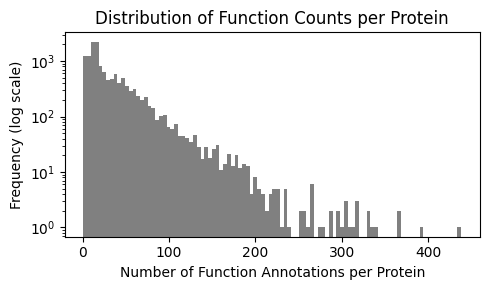

In [20]:
import matplotlib.pyplot as plt

aa_df.groupby("EntryID")["term"].nunique().plot.hist(bins=100, figsize=(5, 3), color="grey", log=True)
plt.xlabel("Number of Function Annotations per Protein")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Function Counts per Protein")
plt.tight_layout()

Graph above reflects a biological reality: many proteins have a small set of well-defined functions, while others are involved wide variety of roles.

In [21]:
from sklearn.model_selection import train_test_split

# 60% of the proteins will be used to train our model
train_aa_data, valid_aa_data = train_test_split(
    list(set(aa_df["EntryID"])),
    test_size=0.4,
    train_size=0.6,
    random_state=42
    )

validation_aa_data, test_aa_data = train_test_split(
    valid_aa_data,
    test_size=0.5,
    random_state=42
)

In [22]:
sequence_splits = {
  "train": aa_df[aa_df["EntryID"].isin(train_aa_data)],
  "valid": aa_df[aa_df["EntryID"].isin(validation_aa_data)],
  "test": aa_df[aa_df["EntryID"].isin(test_aa_data)],
}

for split, df in sequence_splits.items():
  print(f"{split} has {len(df)} entries.")

train has 272030 entries.
valid has 92135 entries.
test has 95087 entries.


In [23]:
import os

csv_dir = "processed_csvs"
os.makedirs(csv_dir, exist_ok=True)

for split,df in sequence_splits.items():

    file_path = os.path.join(csv_dir, f"{split}_sequenced_df.csv")

    # index=False prevents pandas from adding extra, unwanted column 
    df.to_csv(file_path, index=False)
    
    print(f"✅ Saved {split} ({len(df)} rows) to {file_path}")

✅ Saved train (272030 rows) to processed_csvs/train_sequenced_df.csv
✅ Saved valid (92135 rows) to processed_csvs/valid_sequenced_df.csv
✅ Saved test (95087 rows) to processed_csvs/test_sequenced_df.csv


Now that data has been split into 60% train, 20% validation, and 20% test- lets move on 
to convert the protein sequences into embeddings that our neural network will actually work with.

Will import the code that the authors wrote for this step. 

In [24]:
# Check the distribution of sequence lengths
lengths = sequence_splits['train']['Sequence'].str.len()
print(f"Average length: {lengths.mean():.2f}")
print(f"Max length: {lengths.max()}")
print(f"Min length: {lengths.min()}")

# See the first 5 lengths
print("First 5 sequence lengths:", lengths.head().tolist())

Average length: 296.06
Max length: 500
Min length: 11
First 5 sequence lengths: [258, 258, 258, 258, 258]


Below I create a pivot data table of my df from up above. While it may look like I lost data, what happened is that a unique
protein may have up to 50 or more functions; when creating a pivot table, each row corresponds to a unique protein and 
`GO:` columns will specify whether that protein corresponds to a certain function through 1s & 0s.

This may actually work out better when it comes time to train our model as getting several identical protein sequences,
each with a different function label would confuse the neural network & worsen performance. 

In [34]:
# 1. Load all three masters
train_m = pd.read_parquet("processed_data_final_merge/train_master.parquet")
valid_m = pd.read_parquet("processed_data_final_merge/valid_master.parquet")
test_m  = pd.read_parquet("processed_data_final_merge/test_master.parquet")

# 2. Find every single unique GO term across the WHOLE project
# This ensures a "Master Checklist"
all_terms = pd.concat([train_m['term'], valid_m['term'], test_m['term']]).unique()
all_go_cols = [f"GO:{t}" if str(t).isdigit() else t for t in all_terms]
all_go_cols.sort()

def process_split(master_df, go_columns):
    embedding_cols = [c for c in master_df.columns if c.startswith("ME:")]
    meta_cols = ["EntryID", "Sequence", "Length"]
    
    # Pivot labels
    labels = (
        master_df[meta_cols + ["term"]]
        .assign(value=1)
        .pivot_table(index=meta_cols, columns="term", values="value", fill_value=0)
        .reset_index()
    )
    labels.columns = [f"GO:{c}" if str(c).isdigit() else c for c in labels.columns]
    
    # CRITICAL STEP: Reindex to match the Master Checklist
    # This adds the missing "rare" GO columns as all 0s
    labels = labels.reindex(columns=meta_cols + go_columns, fill_value=0)
    
    # Group embeddings
    embs = master_df.groupby("EntryID")[embedding_cols].mean().reset_index()
    
    # Final Merge
    return pd.merge(labels, embs, on="EntryID")

# Apply to all three
train_df = process_split(train_m, all_go_cols)
valid_df = process_split(valid_m, all_go_cols)
test_df  = process_split(test_m, all_go_cols)

print(f"Train: {train_df.shape} | Val: {valid_df.shape} | Test: {test_df.shape}")

Train: (8269, 2566) | Val: (2756, 2566) | Test: (2757, 2566)


In [35]:
train_df.head(5)

,EntryID,Sequence,Length,GO:0000018,GO:0000041,GO:0000070,GO:0000075,GO:0000077,GO:0000079,GO:0000082,...,ME:631,ME:632,ME:633,ME:634,ME:635,ME:636,ME:637,ME:638,ME:639,ME:640
0,A0A023T787,MADVLDLHEAGGEDFAMDEDGDESIHKLKEKAKKRKGRGFGSEEGS...,174,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.164547,-0.044116,0.328103,-0.003999,0.062327,0.057994,0.049423,-0.006416,-0.084593,0.077739
1,A0A024QYT6,MMRFMLLFSRQGKLRLQKWYLATSDKERKKMVRELMQVVLARKPKM...,158,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.141159,-0.136460,0.296931,-0.007098,0.011701,0.171209,0.031584,0.027123,-0.134326,0.031552
2,A0A024QYX0,MTTNAGPLHPYWPQHLRLDNFVPNDRPTWHILAGLFSVTGVLVVTT...,230,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.086512,-0.091791,-0.053287,-0.020990,-0.077382,0.133854,-0.003258,0.008998,-0.085945,-0.000293
3,A0A024QYX2,MFVASERKMRAHQVLTFLLLFVITSVASENASTSRGCGLDLLPQYV...,403,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.109935,-0.059675,-0.067857,0.010096,-0.145963,0.092836,-0.004469,0.000830,-0.123183,-0.128601
4,A0A024QYX3,MSSEEGKLFVGGLNFNTDEQALEDHFSSFGPISEVVVVKDRETQRS...,157,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.194585,0.008628,0.476002,-0.135660,-0.009447,0.075722,0.081115,-0.169340,0.033921,0.086374


In [36]:
valid_df.head(5)

,EntryID,Sequence,Length,GO:0000018,GO:0000041,GO:0000070,GO:0000075,GO:0000077,GO:0000079,GO:0000082,...,ME:631,ME:632,ME:633,ME:634,ME:635,ME:636,ME:637,ME:638,ME:639,ME:640
0,A0A024QZ02,MAFSGSQAPYLSPAVPFSGTIQGGLQDGLQITVNGTVLSSSGTRFA...,323,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.007841,0.070930,0.082247,-0.030311,0.012863,0.116248,-0.154663,-0.057282,-0.106856,-0.076006
1,A0A024QZC4,MATFPPATSAPQQPPGPEDEDSSLDESDLYSLAHSYLGGGGRKGRT...,82,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.060093,-0.051436,0.251024,-0.088195,0.007703,0.116386,-0.028761,0.010028,0.024755,0.059531
2,A0A024QZN7,MSLTSSSSVRVEWIAAVTIAAGTAAIGYLAYKRFYVKDHRNKAMIN...,108,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.134696,-0.016241,-0.034367,-0.001577,0.164601,0.093924,-0.000731,0.026580,-0.135359,0.085158
3,A0A024QZS2,MSKSCGNNLAAISVGISLLLLLVVCGIGCVWHWKHRVATRFTLPRF...,157,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.051699,0.103339,0.517210,-0.083294,-0.017104,0.106242,-0.037836,-0.002200,0.023733,-0.122536
4,A0A024R012,MRPLQIVPSRLISQLYCGLKPPASTRNQICLKMARPSSSMADFRKF...,310,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.009774,-0.000150,0.016693,-0.077979,-0.007920,0.065571,-0.091760,0.045579,-0.126128,-0.020068


In [37]:
test_df.head(5)

,EntryID,Sequence,Length,GO:0000018,GO:0000041,GO:0000070,GO:0000075,GO:0000077,GO:0000079,GO:0000082,...,ME:631,ME:632,ME:633,ME:634,ME:635,ME:636,ME:637,ME:638,ME:639,ME:640
0,A0A024QZ59,MPGFDYKFLEKPKRRLLCPLCGKPMREPVQVSTCGHRFCDTCLQEF...,470,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.058604,0.028250,-0.200121,0.053701,-0.130789,0.094496,-0.090869,0.020982,-0.157413,-0.131064
1,A0A024QZA9,MILASVLRSGPGGGLPLRPLLGPALALRARSTSATDTHHVEMARER...,412,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.011233,-0.101400,-0.343504,-0.074603,-0.135175,0.038266,-0.075241,0.019477,-0.157989,-0.007990
2,A0A024QZD1,MGVDIRHNKDRKVRRKEPKSQDIYLRLLVKLYRFLARRTNSTFNQV...,188,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.055722,-0.138710,-0.064941,-0.106044,0.030172,0.090087,-0.069951,-0.064840,-0.064703,0.001674
3,A0A024QZG3,MSLLATLGLELDRALLPASGLGWLVDYGKLPPAPAPLAPYEVLGGA...,282,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.130072,0.032303,-0.147534,-0.126276,-0.082390,0.128639,-0.023388,-0.016077,-0.076585,-0.046674
4,A0A024QZP7,MEDYTKIEKIGEGTYGVVYKGRHKTTGQVVAMKKIRLESEEEGVPS...,297,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.004075,0.029477,0.101056,-0.012480,-0.118313,0.008180,-0.072401,0.025143,-0.326040,-0.024465


In [38]:
from torch.utils.data import Dataset, DataLoader

class ProteinDataset(Dataset):
    def __init__(self, df):
        # Extract the embeddings
        self.embeddings = torch.tensor(
            df.filter(regex="^ME:").values, dtype=torch.float32
        )

        # Extract target that our model will try to predict
        self.targets = torch.tensor(
            df.filter(regex="^GO:").values, dtype=torch.float32
        )

    def __len__(self):
        return len(self.embeddings)
    
    def __getitem__(self, index):
        return self.embeddings[index], self.targets[index]
    
batch_size = 32
train_loader = DataLoader(ProteinDataset(train_df), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(ProteinDataset(valid_df), batch_size=batch_size)
test_loader  = DataLoader(ProteinDataset(test_df), batch_size=batch_size)

In [39]:
# This gives you the first BATCH
embeddings, targets = next(iter(test_loader))

print(f"Batch Embeddings Shape: {embeddings.shape}") # Should be [32, 640]
print(f"Batch Targets Shape: {targets.shape}")       # Should be [32, 1923]

Batch Embeddings Shape: torch.Size([32, 640])
Batch Targets Shape: torch.Size([32, 1923])


In [40]:
import torch.nn as nn 

class ProteinFunctionNetwork(nn.Module):

    def __init__(self, input_dim=640, output_dim=1923):
        super().__init__()
        self.neural_network = nn.Sequential(

            # Layer 1
            nn.Linear(in_features=input_dim, out_features=1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.15),

            # Layer 2
            nn.Linear(in_features=1024, out_features=1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.15),

            # Layer 3
            nn.Linear(in_features=1024, out_features=1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.15),

            # Layer 4 (Classification Layer that predicts protein function(s))
            nn.Linear(in_features=1024, out_features=output_dim)

        )

    def forward(self, x):
        return self.neural_network(x)

In [41]:
# Setup device (MacBook Air GPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Initialize model
num_labels = train_df.filter(regex="^GO:").shape[1]
model = ProteinFunctionNetwork(input_dim=640, output_dim=num_labels).to(device)

print(f"Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters.")

Model initialized with 4,732,803 parameters.


In [42]:
from sklearn import metrics
import numpy as np

def compute_metrics(targets, probs, thresh=0.5):
    """
    Translation of the author's compute_metrics into PyTorch-friendly logic.
    targets: numpy array of 0s and 1s
    probs: numpy array of predicted probabilities (0.0 to 1.0)
    """
    # If the protein has no labels (rare but possible), return zeros
    if np.sum(targets) == 0:
        return {m: 0.0 for m in ["accuracy", "recall", "precision", "auprc", "auroc"]}

    preds = (probs >= thresh).astype(int)
    
    return {
        "accuracy": metrics.accuracy_score(targets, preds),
        "recall": metrics.recall_score(targets, preds, zero_division=0),
        "precision": metrics.precision_score(targets, preds, zero_division=0),
        "auprc": metrics.average_precision_score(targets, probs),
        # Using try/except because AUROC fails if a sample has only one class
        "auroc": metrics.roc_auc_score(targets, probs) if len(np.unique(targets)) > 1 else 0.5
    }

def validate_model(model, loader, device, criterion=None):
    model.eval()
    all_batch_metrics = []
    total_loss = 0.0
    
    with torch.no_grad():
        for embeddings, targets in loader:
            embeddings, targets = embeddings.to(device), targets.to(device)
            
            # Get model predictions (logits)
            logits = model(embeddings)

            # Calculate Loss
            if criterion != None:
                loss = criterion(logits, targets)
                total_loss += loss

            # Apply Sigmoid to get probabilities (0 to 1)
            probs = torch.sigmoid(logits).cpu().numpy()
            targets_np = targets.cpu().numpy()

            # Calculate metrics for each protein in the batch (Author's logic)
            for i in range(len(targets_np)):
                m = compute_metrics(targets_np[i], probs[i])
                all_batch_metrics.append(m)
                
    # Average the metrics across all proteins
    summary_df = pd.DataFrame(all_batch_metrics).mean()
    results = summary_df.to_dict()

    if criterion != None:
        results['loss'] = total_loss / len(loader)
        
    return results

In [49]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Calculate standard BCE loss
        # We use 'none' to keep the loss for each label separate before weighting
        ce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        
        # Get the probability of the true class
        p_t = torch.exp(-ce_loss) 
        
        # Calculate Focal Loss: (1-p_t)^gamma * BCE
        focal_loss = self.alpha * (1 - p_t)**self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

In [ ]:
# Loss and Optimizer
criterion = FocalLoss(alpha=0.5, gamma=1.5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Initialize history to capture everything
history = {
    'train_auprc': [], 'val_auprc': [],
    'train_loss': [], 'val_loss': []
}
epochs = 30

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0
    
    for embeddings, targets in train_loader:
        embeddings, targets = embeddings.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(embeddings)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() # .item() converts tensor to float

    # --- VALIDATION PHASE ---
    # CRITICAL: We pass 'criterion' here so it calculates the loss!
    val_results = validate_model(model, val_loader, device, criterion=criterion)
    
    # Also calculate training metrics for a side-by-side comparison
    train_results = validate_model(model, train_loader, device, criterion=criterion)

    # --- RECORDING RESULTS ---
    history['train_loss'].append(running_train_loss / len(train_loader))
    history['val_loss'].append(val_results['loss'].item()) # .item() ensures it's a float
    
    history['train_auprc'].append(train_results['auprc'])
    history['val_auprc'].append(val_results['auprc'])

    print(f"Epoch {epoch+1:02d} | "
          f"Loss (Train/Val): {history['train_loss'][-1]:.4f} / {history['val_loss'][-1]:.4f} | "
          f"AUPRC (Train/Val): {train_results['auprc']:.4f} / {val_results['auprc']:.4f}")

In [ ]:
plt.figure(figsize=(12, 5))

# Plot AUPRC
plt.subplot(1, 2, 1)
plt.plot(history['train_auprc'], label='Train AUPRC', color='blue')
plt.plot(history['val_auprc'], label='Val AUPRC', color='orange')
plt.title('AUPRC over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUPRC')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
# Note: You'll need to ensure validate_model calculates/returns 'loss' for the val_loss line
if 'val_loss' in history:
    plt.plot(history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

After trying many iterations of focal loss along with the deep learning architecture from up above,
I want to try something new. I will attempt to build a Residual Neural Network. I hope that this
new architecture type will yield better results as they have skips connections, batch normalization, and
a slightly different order of operations within each layer.

In [43]:
class ResidualBlock(nn.Module):
    def __init__(self, size, dropout=0.25):
        super().__init__()
        self.res_block = nn.Sequential(
            nn.Linear(in_features=size, out_features=size),
            nn.BatchNorm1d(size),
            nn.SiLU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return x + self.res_block(x)

class ProteinFunctionResidualNetwork(nn.Module):
    def __init__(self, input_dim=640, output_dim=1923):
        super().__init__()

        # Initial layer is standard layer with batch normalization
        self.initial_layer = nn.Sequential(
            nn.Linear(in_features=input_dim, out_features=1024),
            nn.SiLU(),
            nn.BatchNorm1d(1024)
        )

        # Residual layers
        self.res_layer1 = ResidualBlock(size=1024, dropout=0.25)
        self.res_layer2 = ResidualBlock(size=1024, dropout=0.25)
        # self.res_layer3 = ResidualBlock(size=1024, dropout=0.25)

        # Final layer that classifies the proteins
        self.classifier = nn.Linear(in_features=1024, out_features=output_dim)

    def forward(self, x):
        x = self.initial_layer(x)
        x = self.res_layer1(x)
        x = self.res_layer2(x)
        # x = self.res_layer3(x)
        return self.classifier(x)

In [44]:
# Setup device (MacBook Air GPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Initialize model
num_labels = train_df.filter(regex="^GO:").shape[1]
model = ProteinFunctionResidualNetwork(input_dim=640, output_dim=num_labels).to(device)

print(f"Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters.")

Model initialized with 4,732,803 parameters.


In [ ]:
# Loss and Optimizer
criterion = FocalLoss(alpha=0.25, gamma=1.5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

# Initialize history to capture everything
history = {
    'train_auprc': [], 'val_auprc': [],
    'train_loss': [], 'val_loss': []
}

epochs = 100

best_val_auprc = 0.0
patience = 5
counter = 0

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    running_train_loss = 0.0

    for embeddings,targets in train_loader:
        embeddings, targets = embeddings.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(embeddings)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    # --- Validation Phase ---
    val_results = validate_model(model, val_loader, device, criterion=criterion)
    
    # Also calculate training metrics for a side-by-side comparison
    train_results = validate_model(model, train_loader, device, criterion=criterion)

    # Update the Scheduler
    scheduler.step(val_results['auprc'])
    current_lr = optimizer.param_groups[0]['lr']

    # Check for Improvement
    if val_results['auprc'] > best_val_auprc:
        best_val_auprc = val_results['auprc']
        torch.save(model.state_dict(), "best_model.pth")
        print(f"🌟 New Best Val AUPRC: {best_val_auprc:.4f} - Model Saved!")
        counter = 0 # Reset early stopping counter
    else:
        counter += 1
        if counter >= patience:
            print(f"🛑 Early stopping at epoch {epoch+1}")
            break

    # --- RECORDING RESULTS ---
    history['train_loss'].append(running_train_loss / len(train_loader))
    history['val_loss'].append(val_results['loss'].item()) # .item() ensures it's a float
    
    history['train_auprc'].append(train_results['auprc'])
    history['val_auprc'].append(val_results['auprc'])

    print(f"Epoch {epoch+1:02d} | "
          f"Loss (Train/Val): {history['train_loss'][-1]:.4f} / {history['val_loss'][-1]:.4f} | "
          f"AUPRC (Train/Val): {train_results['auprc']:.4f} / {val_results['auprc']:.4f}")

In [ ]:
plt.figure(figsize=(12, 5))

# Plot AUPRC
plt.subplot(1, 2, 1)
plt.plot(history['train_auprc'], label='Train AUPRC', color='blue')
plt.plot(history['val_auprc'], label='Val AUPRC', color='orange')
plt.title('AUPRC over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUPRC')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
# Note: You'll need to ensure validate_model calculates/returns 'loss' for the val_loss line
if 'val_loss' in history:
    plt.plot(history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

The residual network yielded extremely modest upgrades to performance. I think the issue is that the
final layer (`nn.Linear(1024, 1923)`) is forcing both model types from above to learn 1923 separate,
isolated relationship. The biological reality is that many labels share similarities- like "ATP Binding"
and "Kinase Activity." To get over this hump, I'll attempt to use attention.

In [45]:
class LabelAttentionHeader(nn.Module):
    def __init__(self, feature_dim, num_labels):
        super().__init__()
        # 1. Create a "Prototype" for every GO term
        # This is a bank of 1923 vectors, each 1024-dim
        self.label_embeddings = nn.Parameter(torch.empty(num_labels, feature_dim))
        nn.init.xavier_uniform_(self.label_embeddings)
        
        # 2. Scaling factor (like in Transformer self-attention)
        # Helps keep the gradients stable as dimensions grow
        self.scale = feature_dim ** -0.5

    def forward(self, x):
        # x: [Batch, 1024] 
        # label_embeddings: [1923, 1024]
        
        # We calculate the dot-product similarity (cosine-adjacent)
        # [Batch, 1024] @ [1024, 1923] -> [Batch, 1923]
        logits = torch.matmul(x, self.label_embeddings.t()) * self.scale
        return logits

class ProteinFunctionAttentionNetwork(nn.Module):
    def __init__(self, input_dim=640, hidden_dim=2048, output_dim=1923):
        super().__init__()

        # Initial layer is standard layer with batch normalization (Same as 'ProteinFunctionResidualNetwork')
        self.initial_layer = nn.Sequential(
            nn.Linear(in_features=input_dim, out_features=hidden_dim),
            nn.SiLU(),
            nn.BatchNorm1d(hidden_dim)
        )

        self.res_layer1 = ResidualBlock(size=hidden_dim, dropout=0.15)
        self.res_layer2 = ResidualBlock(size=hidden_dim, dropout=0.15)

        # Added a non-linear projection before the Attention Header
        self.feature_projection = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.LayerNorm(hidden_dim)
        )

        self.classifier = LabelAttentionHeader(feature_dim=hidden_dim, num_labels=output_dim)

    def forward(self, x):
        x = self.initial_layer(x)
        x = self.res_layer1(x)
        x = self.res_layer2(x)
        x = self.feature_projection(x)
        return self.classifier(x)

In [46]:
# Setup device (MacBook Air GPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Initialize model
num_labels = train_df.filter(regex="^GO:").shape[1]
model = ProteinFunctionAttentionNetwork(input_dim=640, output_dim=num_labels).to(device)

print(f"Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters.")

Model initialized with 17,856,512 parameters.


In [50]:
# Loss and Optimizer
criterion = FocalLoss(alpha=0.25, gamma=1.5)
optimizer = torch.optim.AdamW(model.parameters(), lr=3.1e-5, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

# Initialize history to capture everything
history = {
    'train_auprc': [], 'val_auprc': [],
    'train_loss': [], 'val_loss': []
}

epochs = 100

best_val_auprc = 0.0
patience = 10
counter = 0

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    running_train_loss = 0.0

    for embeddings,targets in train_loader:
        embeddings, targets = embeddings.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(embeddings)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    # --- Validation Phase ---
    val_results = validate_model(model, val_loader, device, criterion=criterion)
    
    # Also calculate training metrics for a side-by-side comparison
    train_results = validate_model(model, train_loader, device, criterion=criterion)

    # Update the Scheduler
    scheduler.step(val_results['auprc'])
    current_lr = optimizer.param_groups[0]['lr']

    # Check for Improvement
    if val_results['auprc'] > best_val_auprc:
        best_val_auprc = val_results['auprc']
        torch.save(model.state_dict(), "best_model.pth")
        print(f"🌟 New Best Val AUPRC: {best_val_auprc:.4f} - Model Saved!")
        counter = 0 # Reset early stopping counter
    else:
        counter += 1
        if counter >= patience:
            print(f"🛑 Early stopping at epoch {epoch+1}")
            break

    # --- RECORDING RESULTS ---
    history['train_loss'].append(running_train_loss / len(train_loader))
    history['val_loss'].append(val_results['loss'].item()) # .item() ensures it's a float
    
    history['train_auprc'].append(train_results['auprc'])
    history['val_auprc'].append(val_results['auprc'])

    print(f"Epoch {epoch+1:02d} | "
          f"Loss (Train/Val): {history['train_loss'][-1]:.4f} / {history['val_loss'][-1]:.4f} | "
          f"AUPRC (Train/Val): {train_results['auprc']:.4f} / {val_results['auprc']:.4f}")

🌟 New Best Val AUPRC: 0.5105 - Model Saved!
Epoch 01 | Loss (Train/Val): 0.0466 / 0.0344 | AUPRC (Train/Val): 0.5164 / 0.5105
🌟 New Best Val AUPRC: 0.5469 - Model Saved!
Epoch 02 | Loss (Train/Val): 0.0274 / 0.0218 | AUPRC (Train/Val): 0.5514 / 0.5469
🌟 New Best Val AUPRC: 0.5610 - Model Saved!
Epoch 03 | Loss (Train/Val): 0.0182 / 0.0153 | AUPRC (Train/Val): 0.5651 / 0.5610
🌟 New Best Val AUPRC: 0.5648 - Model Saved!
Epoch 04 | Loss (Train/Val): 0.0133 / 0.0117 | AUPRC (Train/Val): 0.5687 / 0.5648
🌟 New Best Val AUPRC: 0.5665 - Model Saved!
Epoch 05 | Loss (Train/Val): 0.0105 / 0.0096 | AUPRC (Train/Val): 0.5704 / 0.5665
🌟 New Best Val AUPRC: 0.5672 - Model Saved!
Epoch 06 | Loss (Train/Val): 0.0089 / 0.0084 | AUPRC (Train/Val): 0.5711 / 0.5672
🌟 New Best Val AUPRC: 0.5677 - Model Saved!
Epoch 07 | Loss (Train/Val): 0.0079 / 0.0076 | AUPRC (Train/Val): 0.5716 / 0.5677
🌟 New Best Val AUPRC: 0.5679 - Model Saved!
Epoch 08 | Loss (Train/Val): 0.0072 / 0.0071 | AUPRC (Train/Val): 0.5718 /

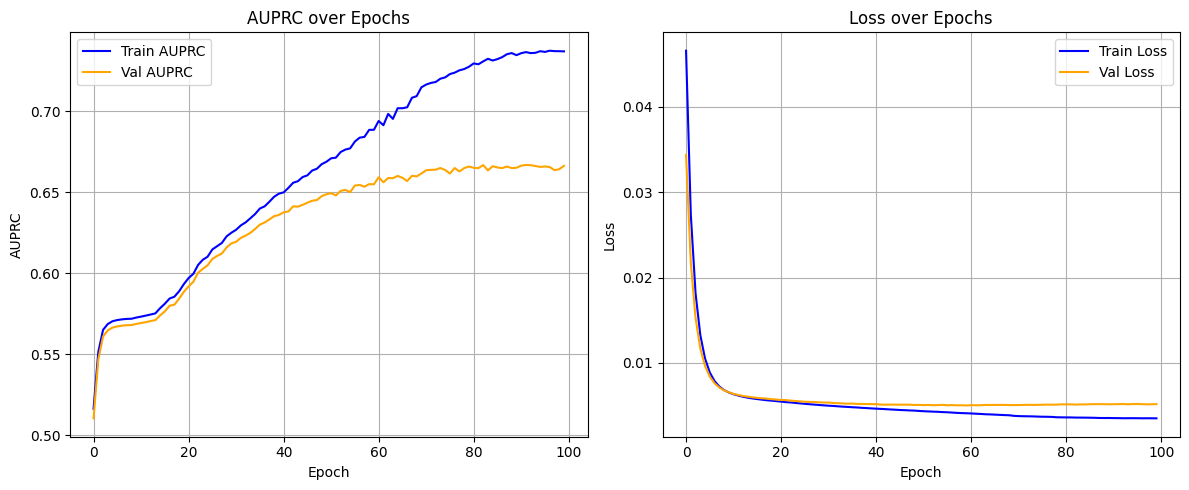

In [51]:
plt.figure(figsize=(12, 5))

# Plot AUPRC
plt.subplot(1, 2, 1)
plt.plot(history['train_auprc'], label='Train AUPRC', color='blue')
plt.plot(history['val_auprc'], label='Val AUPRC', color='orange')
plt.title('AUPRC over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUPRC')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
# Note: You'll need to ensure validate_model calculates/returns 'loss' for the val_loss line
if 'val_loss' in history:
    plt.plot(history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# # 1. Run the evaluation
# print("🧪 Running Final Blind Test...")
# test_results = validate_model(model, test_loader, device, criterion=criterion)

# # 2. Print the official report
# print("\n" + "="*30)
# print("       FINAL TEST RESULTS")
# print("="*30)
# print(f"Test AUPRC:     {test_results['auprc']:.4f}")
# print(f"Test AUROC:     {test_results['auroc']:.4f}")
# print(f"Test Precision: {test_results['precision']:.4f}")
# print(f"Test Recall:    {test_results['recall']:.4f}")
# print(f"Test Loss:      {test_results['loss']:.4f}")
# print("="*30)

In [ ]:
print(type(model))

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
print("✅ Weights loaded successfully!")

In [ ]:
# 1. Force load the best version
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# 2. Check the raw outputs for one batch
with torch.no_grad():
    embeddings, targets = next(iter(test_loader))
    outputs = model(embeddings.to(device))
    print(f"Max logit: {outputs.max().item():.4f}")
    print(f"Min logit: {outputs.min().item():.4f}")
    print(f"Mean logit: {outputs.mean().item():.4f}")

In [ ]:
# Ensure the model is in evaluation mode (turns off Dropout/BatchNorm updates)
model.eval()

# Run the validation/test function
test_results = validate_model(model, test_loader, device, criterion=criterion)

print("==============================")
print("       REAL TEST RESULTS")
print("==============================")
print(f"Test AUPRC:     {test_results['auprc']:.4f}")
print(f"Test AUROC:     {test_results['auroc']:.4f}")
print(f"Test Loss:      {test_results['loss']:.4f}")
print("==============================")